In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# grid map 
**A * algo**

Shortest Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


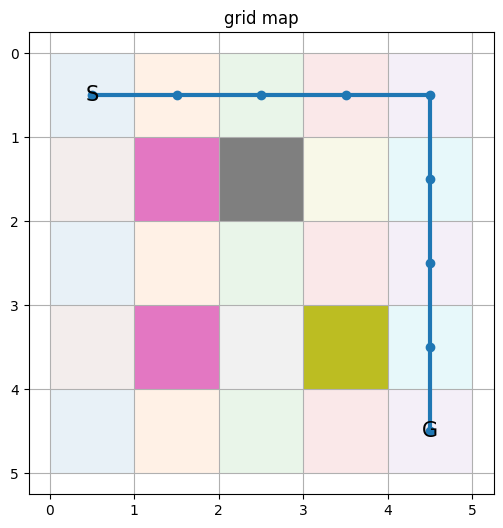

In [5]:
import heapq 
import matplotlib.pyplot as plt

grid = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 4)


# Heuristic function (Manhattan Distance)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# A* Algorithm
def a_star(grid, start, goal):

    rows = len(grid)
    cols = len(grid[0])

    # Priority Queue
    pq = []

    # (f, g, node, path)
    heapq.heappush(pq, (heuristic(start, goal), 0, start, [start]))

    visited = set()

    while pq:

        f, g, current, path = heapq.heappop(pq)

        if current in visited:
            continue

        visited.add(current)

        # Goal reached
        if current == goal:
            return path

        r, c = current

        # Up, Down, Left, Right
        directions = [
            (-1, 0),
            (1, 0),
            (0, -1),
            (0, 1)
        ]

        for dr, dc in directions:

            nr = r + dr
            nc = c + dc

            # Check valid position
            if (0 <= nr < rows and
                0 <= nc < cols and
                grid[nr][nc] == 0):

                neighbor = (nr, nc)

                if neighbor not in visited:

                    new_g = g + 1
                    new_f = new_g + heuristic(neighbor, goal)

                    heapq.heappush(
                        pq,
                        (new_f, new_g, neighbor, path + [neighbor])
                    )

    return None


# Find path
path = a_star(grid, start, goal)

print("Shortest Path:")
print(path)


# Draw Grid
plt.figure(figsize=(6, 6))

for r in range(len(grid)):
    for c in range(len(grid[0])):

        if grid[r][c] == 1:
            plt.fill_between(
                [c, c + 1],
                r, r + 1
            )

        else:
            plt.fill_between(
                [c, c + 1],
                r, r + 1,
                alpha=0.1
            )

# Draw path
if path:
    x = [p[1] + 0.5 for p in path]
    y = [p[0] + 0.5 for p in path]

    plt.plot(x, y, marker='o', linewidth=3)

# Start and Goal
plt.text(start[1] + 0.5, start[0] + 0.5,
         "S", ha="center", va="center", fontsize=15)

plt.text(goal[1] + 0.5, goal[0] + 0.5,
         "G", ha="center", va="center", fontsize=15)

# Grid settings
plt.xticks(range(6))
plt.yticks(range(6))
plt.grid(True)

plt.gca().invert_yaxis()

plt.title("grid map")
plt.show()

# implement 8 puzel prob using heuristic search

In [16]:
from heapq import heappush, heappop 

# Manhattan Distance heuristic
def heuristic(state, goal):
    distance = 0

    for i in range(9):
        if state[i] != 0:
            x, y = divmod(i, 3)
            gx, gy = divmod(goal.index(state[i]), 3)
            distance += abs(x - gx) + abs(y - gy)

    return distance


def get_neighbors(state):
    neighbors = []
    zero = state.index(0)
    row, col = divmod(zero, 3)

    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for dr, dc in moves:
        nr, nc = row + dr, col + dc

        if 0 <= nr < 3 and 0 <= nc < 3:
            new_pos = nr * 3 + nc
            new_state = list(state)

            new_state[zero], new_state[new_pos] = \
                new_state[new_pos], new_state[zero]

            neighbors.append(tuple(new_state))

    return neighbors


def a_star(start, goal):
    pq = []
    heappush(pq, (heuristic(start, goal), 0, start))

    parent = {start: None}
    cost = {start: 0}

    while pq:
        f, g, current = heappop(pq)

        if current == goal:
            path = []

            while current is not None:
                path.append(current)
                current = parent[current]

            return path[::-1]

        for neighbor in get_neighbors(current):
            new_cost = g + 1

            if neighbor not in cost or new_cost < cost[neighbor]:
                cost[neighbor] = new_cost
                f = new_cost + heuristic(neighbor, goal)

                heappush(pq, (f, new_cost, neighbor))
                parent[neighbor] = current

    return None


# 0 represents the blank space
start = (1, 2, 3,
         4, 0, 6,
         7, 5, 8)

goal = (1, 2, 3,
        4, 5, 6,
        7, 8, 0)

solution = a_star(start, goal)

if solution:
    print("Solution found!")
    print("Number of moves:", len(solution) - 1)

    for state in solution:
        for i in range(0, 9, 3):
            print(state[i:i+3])
        print()
else:
    print("No solution found.")

Solution found!
Number of moves: 2
(1, 2, 3)
(4, 0, 6)
(7, 5, 8)

(1, 2, 3)
(4, 5, 6)
(7, 0, 8)

(1, 2, 3)
(4, 5, 6)
(7, 8, 0)

